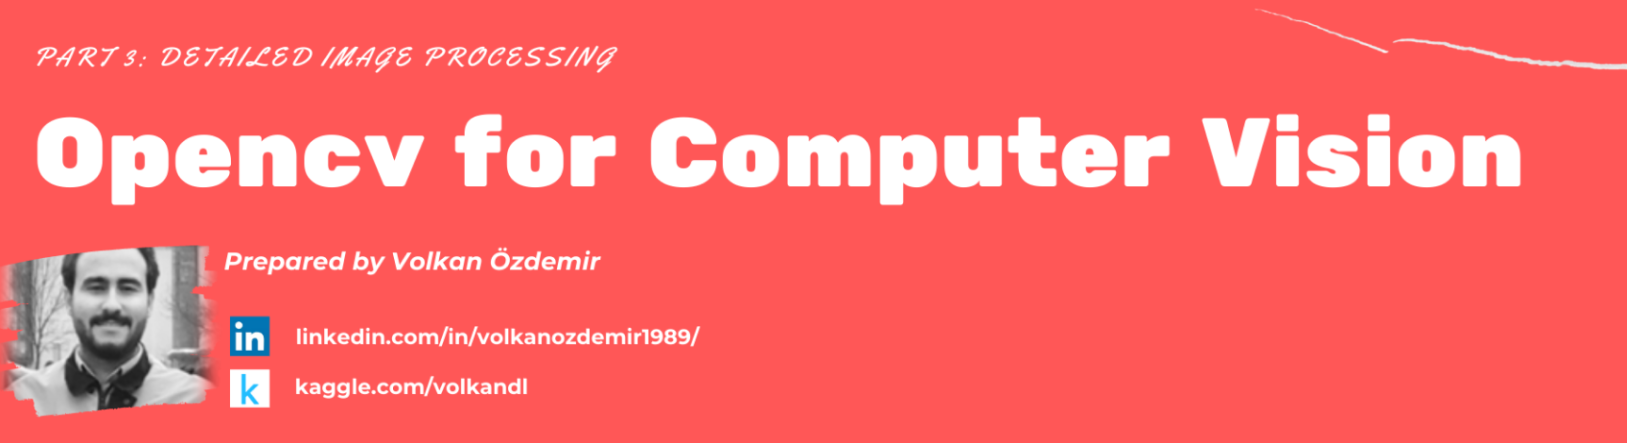

In [16]:
import os
for root, dirs, files in os.walk('/kaggle/input'):
    for f in files:
        if 'test-size-chan' in f.lower():
            print(os.path.join(root, f))

In [17]:
pip install opencv-python numpy matplotlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


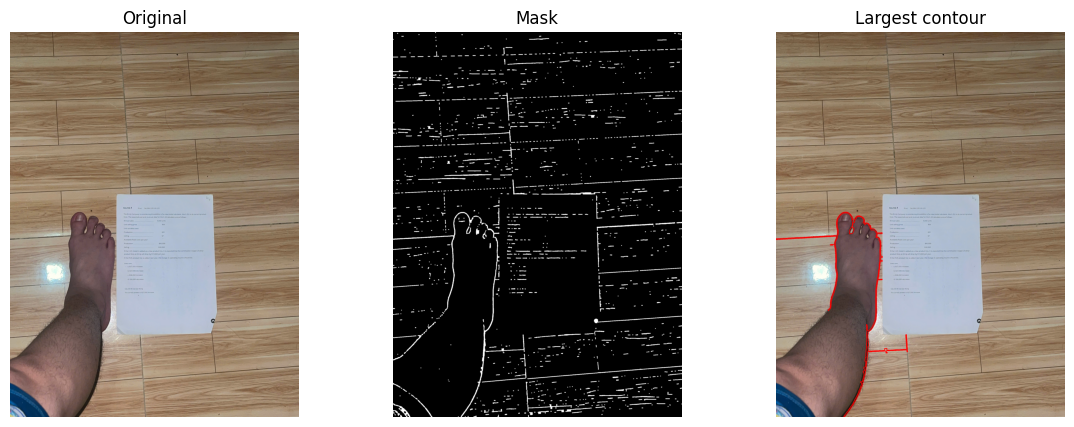

Contour area: 21566.0


In [18]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img_path = r"C:\Users\giahu\Downloads\test-size-chan-2.jpg"
img = cv2.imread(img_path)

if img is None:
    raise FileNotFoundError(f"Không đọc được ảnh: {img_path}")

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray, (5,5), 0)

# adaptive threshold để chịu ánh sáng không đều
th = cv2.adaptiveThreshold(
    blur, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 31, 7
)

# khử nhiễu + làm đầy
kernel = np.ones((5,5), np.uint8)
mask = cv2.morphologyEx(th, cv2.MORPH_OPEN, kernel, iterations=1)
mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)

contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# lấy contour lớn nhất (giả định là bàn chân)
cnt = max(contours, key=cv2.contourArea)

# vẽ contour
vis = img_rgb.copy()
cv2.drawContours(vis, [cnt], -1, (255, 0, 0), 3)

plt.figure(figsize=(14,5))
plt.subplot(1,3,1); plt.title("Original"); plt.imshow(img_rgb); plt.axis("off")
plt.subplot(1,3,2); plt.title("Mask"); plt.imshow(mask, cmap="gray"); plt.axis("off")
plt.subplot(1,3,3); plt.title("Largest contour"); plt.imshow(vis); plt.axis("off")
plt.show()

print("Contour area:", cv2.contourArea(cnt))

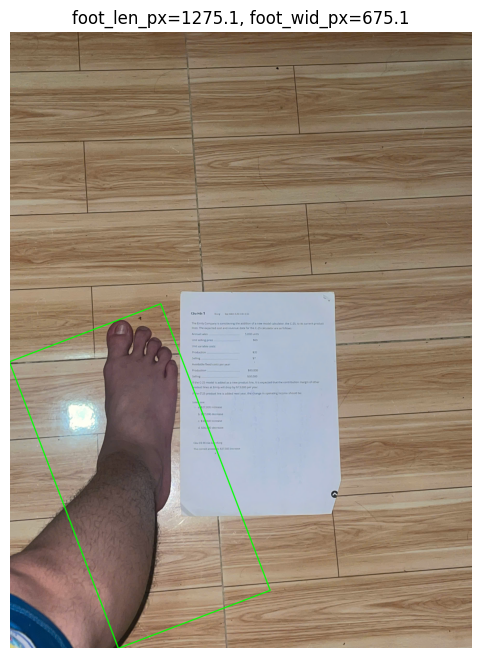

foot_len_px: 1275.095947265625
foot_wid_px: 675.0574951171875


In [19]:
rect = cv2.minAreaRect(cnt)              # ((cx,cy), (w,h), angle)
(w, h) = rect[1]
foot_len_px = max(w, h)                  # cạnh dài xem như chiều dài chân
foot_wid_px = min(w, h)

box = cv2.boxPoints(rect)
box = np.int32(box)

vis2 = img_rgb.copy()
cv2.drawContours(vis2, [box], 0, (0,255,0), 3)

plt.figure(figsize=(6,8))
plt.title(f"foot_len_px={foot_len_px:.1f}, foot_wid_px={foot_wid_px:.1f}")
plt.imshow(vis2)
plt.axis("off")
plt.show()

print("foot_len_px:", foot_len_px)
print("foot_wid_px:", foot_wid_px)

### ****$\color{orange}{\text{If You want to be an AI Expert, Knowing Deep learning is never enough alone!}}$****

### $\color{Pink}{\text{Table of Contents  }}$

* [Chapter 1. Image Moments](#chapter1)     
* [Chapter 2. Sorting the Contours](#chapter2)
    * [Section 2.1 Sorting by Area ](#section2_1)
    * [Section 2.2 Sorting by Location ](#section2_2)
* [Chapter 3. Drawing a Rectangle & Convex Hull over the Contour](#chapter3)
    * [Section 3.1 Drawing a Rectangle ](#section3_1)
    * [Section 3.2 Drawing a Convex Hull ](#section3_2)
* [Chapter 4. Invariant Contour Propoerties](#chapter4)
    * [Section 4.1 Aspect Ratio ](#section4_1)
    * [Section 4.2 Hu Moments ](#section4_2)


   
    

****$\color{pink}{\text{If You like my work, Please upvote  }}$****


# Introduction

Hi everyone! We continue to deep dive to image processing with OpenCV for Computer Vision, it is a long notebook so keep in tune. If you missed the first two parts, you are welcome to reach from here :

* Lesson 1: [OpenCV for Computer Vision 1 - Beginner](https://www.kaggle.com/volkandl/opencv-for-computer-vision-1-beginner)
* Lesson 2: [OpenCV for Computer Vision 2 - intermediate](https://www.kaggle.com/volkandl/opencv-for-computer-vision-2-intermediate)


Last time we found contours of the blobs in an image by using below mentioned opencv function and check the internal and external contours.

>contours, hier = cv2.findContours(canny, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

In this notebook we will continue with the contours since they are one of the basic features for image processing. I will briefly summarize how we can sort the contours and how to detect the objects by invariant contour properties. Give an upvote if you enjoy! 

In [20]:
#!pip install opencv-contrib-python
import cv2
!pip install --upgrade imutils
import imutils
import math
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
import os

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [21]:
lena = r"/kaggle/input/opencv-samples-images/data/lena.jpg"
chessboard = r"/kaggle/input/opencv-samples-images/data/chessboard.png"
minnions = r"/kaggle/input/opencv-samples-images/minions.jpg"
templ = r"/kaggle/input/opencv-samples-images/data/templ.png"
blob= r"/kaggle/input/opencv-samples-images/data/detect_blob.png"
basketball = r"/kaggle/input/opencv-samples-images/data/basketball2.png"
coffee = r"/kaggle/input/operations-with-opencv/coffee.jpg"
fruits = r"/kaggle/input/opencv-samples-images/data/fruits.jpg"
motion= r"/kaggle/input/opencv-samples-images/data/text_motion.jpg"
coridor = r"/kaggle/input/computer-vision-course/imagenes/corridor.jpg"
mit2 =  r"/kaggle/input/computer-vision-course/imagenes/car.jpg"
hand = r"/kaggle/input/opencv-samples-images/hand.jpg"

# Chapter 1. Image Moments <a class="anchor" id="chapter1"></a>

The centroid of an shape is basically the weighted center of the shape blob in the image. Mathamatically speaking, it is the arithmetic mean of the pixels in the shape.

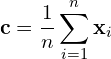

Image Moment is a particular weighted average of image pixel values. By the help of using first moments ratios we can find the x and y coordinate of the centroid. By following formulas:

The centroid is given by the formula:

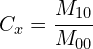

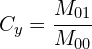

Finding the centroid and the coordinates of the shapes helps us to sort the images by their centroid's coordinates. For clean iamges, it helps a lot to gather the desired feature for problem solving reasons.

In [22]:
contour_image = cv2.imread(templ )
contour_image = cv2.cvtColor(contour_image, cv2.COLOR_BGR2GRAY)
figure(figsize=(18,16), dpi=30)
plt.imshow(contour_image,cmap="gray")

error: OpenCV(4.13.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\color.cpp:199: error: (-215:Assertion failed) !_src.empty() in function 'cv::cvtColor'


OpenCV function helps us to find moments:
>cv2.moments(contour)



In [ ]:
canny = cv2.Canny(contour_image , 120, 255)        
contours, hier = cv2.findContours(canny, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
center_moments= cv2.moments(contours[0])
print(center_moments)

As you can see, cv2.moments() function returns a dictionary increase lots of values starting 

* Spatial moments m00, m01, m10 as first order moments and m11, m20,m02 and the rest as higher order moments.
* Central moments mu20, mu11, mu02 and higher orders moments
* central normalized moments nu20, nu11, nu02 and higher order moments

All moments are calculated with Green's theorem. It states the integral form of finding areas. For further read : https://en.wikipedia.org/wiki/Green%27s_theorem

In [ ]:
x_centroid = int(center_moments["m10"]/center_moments["m00"])
y_centroid = int(center_moments["m01"]/center_moments["m00"])
print( "x coordinate of the centroid is {}, and y coordinate of the centroid is {}".format(x_centroid, y_centroid))
cv2.circle( contour_image, (x_centroid, y_centroid), 5, (255,0,0), -1 )
figure(figsize=(18,16), dpi=30)
plt.imshow(contour_image,cmap="gray")

****$\color{pink}{\text{Moments}}$****

Moments help us to find specific points of a blob in an image such as centroid location. The math behind it is simple and very similar to physics. As you can see , we find the centroid of an contour and put a circle to that point.

# Chapter 2. Sorting the Contours <a class="anchor" id="chapter2"></a>

We have studied cv2.findContours() function in part 2. It finds the contours according to the parameters that we state. Another topic we may interest is sorting the contours after finding it. In some applications such object detection, face detection or measurement, finding the related contours is a need. Soo that, sorting is an important issue to dive deeply.

We can sort the contours by two ways:

* Sorting by area
* Sorting by location

Sorting by area is useful when you are interested in medium-large parts you want to extract from the image or small contours to noise elimination. Sorting by spatial poision helps us to sort the contours left to right or top to bottom.

In [ ]:
image1 = cv2.imread(blob)
image1 = cv2.cvtColor(image1, cv2.COLOR_BGR2RGB)
image2=cv2.imread(blob)
image2 = cv2.cvtColor(image2, cv2.COLOR_BGR2RGB)
im1=cv2.imread(blob)
im1 = cv2.cvtColor(im1, cv2.COLOR_BGR2RGB)


print("shape is: {}".format(image1.shape))
im = image1 #back-up 
w,h,c = image1.shape #shape of the numpy array 
figure(figsize=(18,16), dpi=30)
plt.imshow(image1)

In [ ]:
black = np.zeros((w,h,c)) #Creating a black image in the shape of original input image for the masking issues
image1 = cv2.cvtColor(image1, cv2.COLOR_BGR2GRAY)

In [ ]:
blur = cv2.medianBlur(image1,5)
edged = cv2.Canny(blur,10, 150)

figure(figsize=(18,16), dpi=30)
plt.imshow(edged,cmap="gray")

In [ ]:
contours, hier= cv2.findContours(edged.copy(), cv2.RETR_EXTERNAL,  cv2.CHAIN_APPROX_SIMPLE)
print("{} contours have been detected".format(len(contours)))

figure(figsize=(18,16), dpi=30)
cv2.drawContours(black,contours,-1, (255,0,0),3 )
plt.imshow(black,cmap="gray")
print("Number of detected contours :",len(contours))

In [ ]:
contours, hier= cv2.findContours(edged.copy(), cv2.RETR_EXTERNAL,  cv2.CHAIN_APPROX_SIMPLE)
print("{} contours have been detected".format(len(contours)))

figure(figsize=(18,16), dpi=30)
cv2.drawContours(im,contours,-1, (255,0,0),3)
plt.imshow(im, cmap="gray")

## ****$\color{orange}{\text{Section 2.1 Sorting Contours by the Area}}$**** <a class="anchor"  id="section2_1"></a>



Finding the area in a binary image is just counting the non zero pixels!! Below function calculates the area of the contours.

>cv2.contourArea( contours ) 

In [ ]:
def contour_areas(contours): #Function calculates contour areas and creates a list of the areas with respect to the contours.
    area =[]
    for _ in contours:
        area.append( cv2.contourArea(_) )    
    return area   

areas = contour_areas(contours)
print("The areas are {} pixel square".format(areas))

In [ ]:
img = im1 #duplicate the GRAY SCALE image
sorted_areas = sorted ( contours ,key=contour_areas, reverse = True ) #From largest to smallest

sorted_areas[0] means the contour which has the largest area.

In [ ]:
figure(figsize=(18,16), dpi=30)
cv2.drawContours(img,[sorted_areas[0]] ,-1, (255,0,0),3)
print("The Largest Area Has been Drown")
plt.imshow(img)



## ****$\color{orange}{\text{Section 2.2 Sorting Contours by the Location}}$**** <a class="anchor"  id="section2_2"></a>

We will sort the contours according to spatial locations. We will use the help of moments function.
>cv2.moments ( contours ) 

In [ ]:
img2 = image2.copy()
#We will get X coordinates by this function
def sort_loc2(contours):

    center_moments = cv2.moments(contours)
        
    return ( int(center_moments["m10"]/center_moments["m00"]) )


In [ ]:
#We will find the centroid of the contour by this function

def centroid_loc(img , centroid):
    center_moments = cv2.moments(centroid)
    
    x_centroid = int(center_moments["m10"]/center_moments["m00"])
    y_centroid = int(center_moments["m01"]/center_moments["m00"])
    
    cv2.circle( img, (x_centroid, y_centroid), 10, (255,0,0), -1 )
    
    return img

In [ ]:
spatial_sort = sorted( contours, key=sort_loc2, reverse = False  )

for (i,j) in enumerate(spatial_sort):
    centre = centroid_loc(img , j)

figure(figsize=(18,16), dpi=30)
plt.imshow(img)

In [ ]:
for (i,j) in enumerate(spatial_sort):
    cv2.drawContours(image2, [j] , -1, (255,0,0), 3)
    center_moments = cv2.moments(j)
    x_centroid = int(center_moments["m10"]/center_moments["m00"])
    y_centroid = int(center_moments["m01"]/center_moments["m00"])
    num = str ( i+1 )
    cv2.putText(image2, num, (x_centroid, y_centroid), cv2.FONT_HERSHEY_SIMPLEX, 1, (255,0,255) ,2)
    

figure(figsize=(18,16), dpi=30)
plt.imshow(image2)    

****$\color{pink}{\text{Contour Sorting}}$****

Contours are the basic features of the objects. As the very early step of object detection in computer vision history starts with contour finding and its specialities. By finding its area or spatial position we can detect or divide them in an image.

# Chapter 3. Drawing a Rectangle & Convex Hull over the Contour <a class="anchor" id="chapter3"></a>


## ****$\color{orange}{\text{Section 3.1 Drawing a Rectangle Box over the Contour}}$**** <a class="anchor"  id="section3_1"></a>

We can gather the coordinates and draw a bounding box over the contour we find. Below we will find the  contour and draw a rectangle over it.

In [ ]:
contour = cv2.imread(templ)
contour= cv2.cvtColor(contour, cv2.COLOR_BGR2GRAY)

canny = cv2.Canny(contour , 120, 255)        
contours, hier = cv2.findContours(canny, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

In [ ]:
#You Can Draw a Rectangular over the Contour by:
(x,y,w,h)= cv2.boundingRect(contours[0])
cv2.rectangle( contour, (x,y), (x+w, y+h), (0,220,225),2)
figure(figsize=(18,16), dpi=30)
plt.imshow(contour,cmap="gray")    

## ****$\color{orange}{\text{Section 3.2 Drawing a Convex Hull over the Contour}}$**** <a class="anchor"  id="section3_2"></a>

Hull means the exterior or the shape of the object.The Convex Hull of a shape or a group of points is a tight fitting convex boundary around blob.



In [ ]:
contour = cv2.imread(hand)
contour= cv2.cvtColor(contour, cv2.COLOR_BGR2GRAY)

_,thresh = cv2.threshold(contour , 233, 255,cv2.THRESH_BINARY_INV)   

contours, hier = cv2.findContours(thresh , cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

In [ ]:
w,h=contour.shape
black1 = np.zeros((w,h)) 
figure(figsize=(18,16), dpi=30)
cv2.drawContours(black1,contours,-1, (255,0,0),3 )
plt.imshow(black1,cmap="gray")
print("Number of detected contours :",len(contours))

In [ ]:
chull = cv2.imread(hand)
chull= cv2.cvtColor(chull, cv2.COLOR_BGR2GRAY)

_,thresh = cv2.threshold(chull , 230, 255,cv2.THRESH_BINARY_INV)        
contours, hier = cv2.findContours(thresh , cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

hull = cv2.convexHull( contours[0])

In [ ]:
w,h=contour.shape
black2 =black1.copy()
figure(figsize=(18,16), dpi=30)
cv2.drawContours(black2,[hull],0, (255,0,0),3 )
plt.imshow(black2,cmap="gray")
print("Number of detected contours :",len(contours))

In [ ]:
imdic = [ black1, black2]
titles = [ "contour", "hull"]
figure(figsize=(18,16), dpi=40)

for i in range(2):
    plt.subplot(1,2,i+1), plt.imshow(imdic[i], "gray")
    plt.title(titles[i])
    plt.xticks([]), plt.yticks([])
plt.show()

****$\color{pink}{\text{Conclusion of Convex Hull}}$****

Hull is an exterior boundry over a contour. Sometimes the contour is not an enough feature for classification or detection. Plus, unlikely to contours, Hull gives a known geometric shape enclose the object or contour.

# Chapter 4. Invariant Contour Properties <a class="anchor" id="chapter3"></a>

When we think of certain shape the objects, most of the properties will be change when the object is rotated, shifted or scaled which means the 3D movement (x,y,z) of the object in real life. This movements will change the properties of area, moments etc. However, there are some properties which are totally invariant of 3D movement!! This will help us to find the objects in real life scenerios.

In [ ]:
hand_raw = cv2.imread(hand)
hand_raw = cv2.cvtColor(hand_raw, cv2.COLOR_BGR2GRAY)
h,w=hand_raw.shape
print(hand_raw.shape)
plt.imshow(hand_raw,cmap="gray")

In [ ]:
_,thresh = cv2.threshold(hand_raw  , 230, 255,cv2.THRESH_BINARY_INV)    
contours, _ = cv2.findContours(thresh , cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
black3= np.zeros((w+150,h+150)) 
hand_manup = cv2.drawContours(black3,[contours[0]],0, (255,255,255),3 )
hand_manup=hand_manup.astype(np.uint8)
plt.imshow(hand_manup,cmap="gray")

In [ ]:
hand_scaled = cv2.resize(hand_manup , (int(h/2),int(w/2)), interpolation = cv2.INTER_AREA)
_,hand_scaled = cv2.threshold(hand_scaled , 130, 255, cv2.THRESH_BINARY) 
hand_scaled=hand_scaled.astype(np.uint8)

hand_translation = cv2.warpAffine(hand_manup  , np.float32([[1,0,100],[0,1,50]]), (w*2,h*2))
_,hand_translation  = cv2.threshold(hand_translation  , 130, 255, cv2.THRESH_BINARY) 
hand_translation=hand_translation.astype(np.uint8)

hand_rotated = imutils.rotate_bound(hand_manup , -33)
_,hand_rotated = cv2.threshold(hand_rotated , 130, 255, cv2.THRESH_BINARY) 
hand_rotated=hand_rotated.astype(np.uint8)

imdic = [ hand_manup, hand_scaled,hand_translation,hand_rotated ]
titles = [ "original","Scaled","Scaled & Translation", "Scaled & Rotated"]
figure(figsize=(18,16), dpi=50)

for i in range(4):
    plt.subplot(2,2,i+1), plt.imshow(imdic[i], "gray")
    plt.title(titles[i])
    plt.xticks([]), plt.yticks([])
plt.show()


Now we have 4 different pics, lets see if some properties remain same after those operations

In [ ]:
print(np.unique(hand_manup),
      np.unique(hand_scaled),
      np.unique(hand_translation),
      np.unique(hand_rotated))

print((hand_manup.shape),
      (hand_scaled.shape),
      (hand_translation.shape),
      (hand_rotated.shape))

## ****$\color{orange}{\text{Section 4.1 Aspect Ratio }}$**** <a class="anchor"  id="section4_1"></a>


Even the length or area will certainly change due to translation, rotation and scaling, the aspect ratio which is nothing but thre ratio of the width to height of the object will remain same under the curcumcitations that object would not tilted from the centroid. (Valid for only 2D movement)

In [ ]:
AR= []
for img in imdic:
    (x,y,w,h)= cv2.boundingRect(img)
    aspect_ratio = float ( w / h)
    AR.append(aspect_ratio)

print("Aspect Ratio of Original Shape is {}".format(AR[0]))
print("Aspect Ratio of Scaled is {}".format(AR[1]))
print("Aspect Ratio of Scaled & Translation Shape is {}".format(AR[2]))
print("Aspect Ratio of Scaled & Rotated Shape is {}".format(AR[3]))

## ****$\color{orange}{\text{Section 4.2 Hu Moments}}$**** <a class="anchor"  id="section4_2"></a>

Hu moments are 7 different moments which are derived six absolute orthogonal invariants and one skew orthogonal invariant based upon algebraic invariants,Hu moments are invariant to rotation, translation and scaling! However,hu moments are not enough for shape matching.

*[1] Zhihu Huang, ; Jinsong Leng, (2010). [IEEE 2010 2nd International Conference on Computer Engineering and Technology - Chengdu, China (2010.04.16-2010.04.18)] 2010 2nd International Conference on Computer Engineering and Technology - Analysis of Hu's moment invariants on image scaling and rotation. , (), V7-476–V7-480. doi:10.1109/iccet.2010.5485542 *


*[2] image is taken from:  https://learnopencv.com/shape-matching-using-hu-moments-c-python/*



In [ ]:
center_moments= cv2.moments(hand_raw)
hu_mom = cv2.HuMoments(center_moments)
print(hu_mom)

In [ ]:
Hu_mom= []
for img in imdic:    
    cm = cv2.moments(img)
    hum = cv2.HuMoments(cm)
    Hu_mom.append(hum)


OpenCV provides an easy to use a utility function called matchShapes that takes in two images ( or contours ) and finds the distance between them using Hu Moments. If the result is close to 0, then the two images or contours are matched. The function is using L2 distance to decide the similarity with using HU moments.

>cv2.matchShapes(image1, image2, cv2.CONTOURS_MATHC_I2,0)

In [ ]:
imdic = [ hand_manup, hand_scaled,hand_translation,hand_rotated ]
L2_1 = cv2.matchShapes(hand_manup,hand_scaled,cv2.CONTOURS_MATCH_I2,0)
L2_2 = cv2.matchShapes(hand_manup,hand_translation,cv2.CONTOURS_MATCH_I2,0)
L2_3 = cv2.matchShapes(hand_manup,hand_rotated,cv2.CONTOURS_MATCH_I2,0)
print("the distance of scaling:",L2_1 )
print("the distance of scaling and translation:",L2_2)
print("the distance of scaling and rotation:",L2_3)

****$\color{pink}{\text{Conclusion of Invariant Features}}$****

As you can see, the hu moments of the original image and the manupulated images are really close to each others. The shape matching algorithm is also gives a L2 ( squared root distance ) of the similarities to each other. That means ** hu moments** are scale-translation-rotation invariant properties. So we can use it for searching a common objecte that we know hu moments in object detection

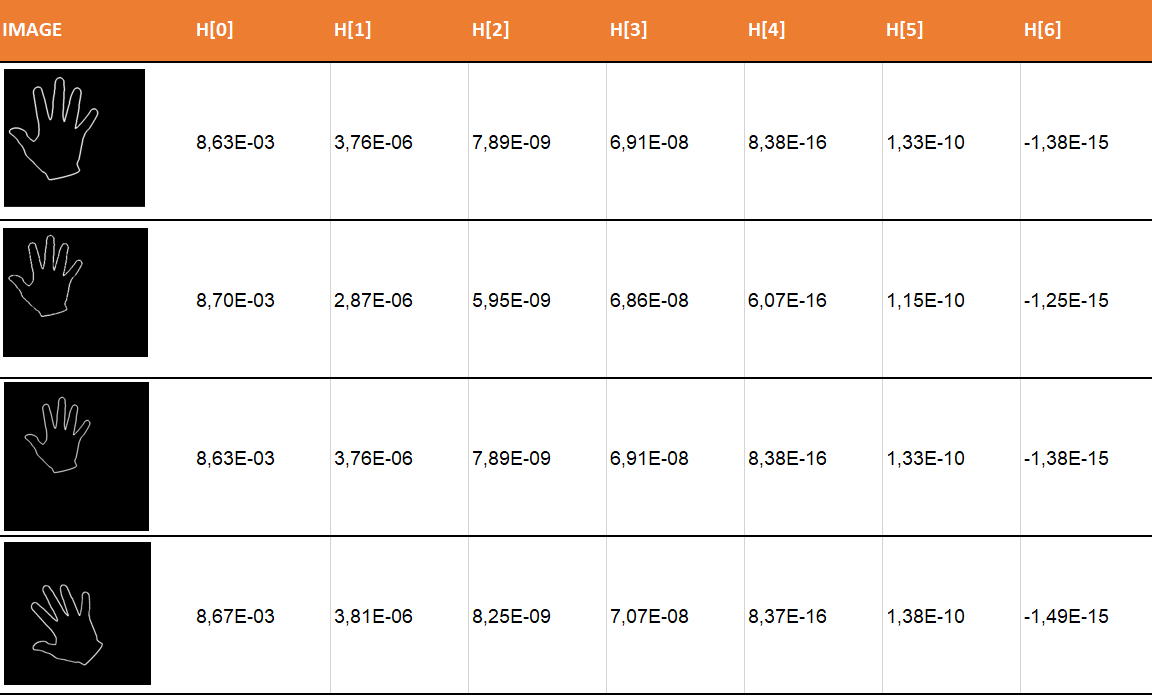